# Métricas de Classificação

## Objetivo

Compreender como avaliar modelos de classificação considerando não apenas
o desempenho estatístico, mas também o impacto dos diferentes tipos de erro
para o negócio.

Neste estudo serão abordados:

- Matriz de Confusão;
- Precision;
- Recall;
- trade-off entre Precision e Recall;
- Threshold;
- Curva Precision-Recall;
- PR AUC;
- MCC;
- KS.

## Onde estamos no CRISP-DM?

Este estudo está concentrado principalmente na etapa de **Avaliação**.

Após construir um modelo, precisamos verificar se seu comportamento é
adequado aos objetivos definidos durante o **Entendimento do Negócio**.

A escolha da métrica depende do problema: diferentes métricas respondem
a diferentes perguntas e diferentes erros podem ter custos distintos
para o negócio.

## 1. Precision

Precision responde à pergunta:

> **Entre todas as observações que o modelo classificou como positivas, quantas eram realmente positivas?**

A métrica considera:

- **VP (Verdadeiro Positivo):** o modelo previu positivo e realmente era positivo.
- **FP (Falso Positivo):** o modelo previu positivo, mas na realidade era negativo.

Assim:

**Precision = VP / (VP + FP)**

### Exemplo

Um modelo identificou 100 transações como fraude.

- 70 realmente eram fraudes → VP = 70
- 30 eram transações legítimas → FP = 30

Portanto:

**Precision = 70 / (70 + 30) = 70%**

Isso significa que, entre todas as transações classificadas como fraude pelo modelo, 70% realmente eram fraudes.

Precision é especialmente relevante quando o custo de um **Falso Positivo** é importante para o negócio.

## 2. Recall

Recall responde à pergunta:

> **Entre todas as observações que realmente eram positivas, quantas o modelo conseguiu identificar como positivas?**

A métrica considera:

- **VP (Verdadeiro Positivo):** o modelo identificou corretamente um positivo.
- **FN (Falso Negativo):** a observação era positiva, mas o modelo a classificou como negativa.

Assim:

**Recall = VP / (VP + FN)**

### Exemplo

Considere 100 pacientes que realmente possuem uma doença:

- 90 foram identificados corretamente → VP = 90
- 10 não foram identificados → FN = 10

Portanto:

**Recall = 90 / (90 + 10) = 90%**

Isso significa que o modelo conseguiu identificar **90% de todos os pacientes realmente positivos**.

Recall é especialmente relevante quando o custo de um **Falso Negativo** é importante para o negócio.

## 3. Precision vs Recall

Embora ambas utilizem os Verdadeiros Positivos, Precision e Recall respondem a perguntas diferentes.

| Métrica | Pergunta principal | Erro que mais afeta |
|---|---|---|
| **Precision** | Dos que o modelo classificou como positivos, quantos realmente eram positivos? | FP |
| **Recall** | Dos que realmente eram positivos, quantos o modelo conseguiu encontrar? | FN |

A escolha entre priorizar Precision ou Recall depende do impacto dos erros no contexto do negócio.

### Exemplos

**Oferta comercial com alto custo por contato:**

Muitos falsos positivos podem gerar gastos desnecessários. Nesse cenário, pode ser importante priorizar **Precision**.

**Detecção de uma doença:**

Um falso negativo pode significar deixar de identificar uma pessoa realmente doente. Nesse cenário, pode ser importante priorizar **Recall**.

### Relação com o custo do erro

A escolha da métrica deve partir do problema de negócio.

- Quando **Falsos Negativos (FN)** são especialmente custosos, o **Recall** tende a ganhar importância, pois queremos evitar deixar positivos reais sem identificação.
- Quando **Falsos Positivos (FP)** são especialmente custosos, a **Precision** tende a ganhar importância, pois queremos que as previsões positivas sejam mais confiáveis.

O desbalanceamento das classes, sozinho, não determina qual métrica deve ser priorizada. É necessário considerar também o objetivo do modelo e o impacto de cada tipo de erro para o negócio.

### Relação entre Recall e TPR

O Recall também é chamado de **TPR (True Positive Rate)** ou **Sensibilidade**.

Assim:

**Recall = TPR = VP / (VP + FN)**

Essa relação conecta Precision e Recall aos conceitos utilizados anteriormente na Curva ROC.

Enquanto a **Curva ROC** observa o comportamento de **TPR (Recall) e FPR** em diferentes thresholds, a **Curva Precision-Recall** observa o comportamento de **Precision e Recall** em diferentes thresholds.

## 4. Exemplo prático com dados desbalanceados

Para analisar Precision e Recall na prática, será criada uma base sintética de classificação com classes desbalanceadas.

O objetivo é simular uma situação em que a classe positiva é menos frequente, como pode ocorrer em problemas de fraude, inadimplência ou detecção de eventos raros.

In [1]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    weights=[0.95, 0.05],
    random_state=42
)

In [2]:
import pandas as pd

pd.Series(y).value_counts()

0    944
1     56
Name: count, dtype: int64

In [3]:
pd.Series(y).value_counts(normalize=True)

0    0.944
1    0.056
Name: proportion, dtype: float64

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Divisão entre treino e teste

Os dados foram separados em 80% para treino e 20% para teste.

Foi utilizado `stratify=y` para preservar aproximadamente a proporção das classes nos conjuntos de treino e teste. Isso é especialmente importante neste exemplo devido ao desbalanceamento entre as classes.

In [5]:
print("Treino:")
print(pd.Series(y_train).value_counts())

print("\nTeste:")
print(pd.Series(y_test).value_counts())

Treino:
0    755
1     45
Name: count, dtype: int64

Teste:
0    189
1     11
Name: count, dtype: int64


In [6]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    random_state=42
)

modelo.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [7]:
probabilidades = modelo.predict_proba(X_test)

print(probabilidades[:10])

[[0.9896069  0.0103931 ]
 [0.99036351 0.00963649]
 [0.98458523 0.01541477]
 [0.98253935 0.01746065]
 [0.99535314 0.00464686]
 [0.90983867 0.09016133]
 [0.99429108 0.00570892]
 [0.95682418 0.04317582]
 [0.99597994 0.00402006]
 [0.94612358 0.05387642]]


In [8]:
y_score = probabilidades[:, 1]

print(y_score[:10])

[0.0103931  0.00963649 0.01541477 0.01746065 0.00464686 0.09016133
 0.00570892 0.04317582 0.00402006 0.05387642]


In [9]:
threshold = 0.50

y_pred = (y_score >= threshold).astype(int)

In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("VP:", tp)
print("FP:", fp)
print("VN:", tn)
print("FN:", fn)

print("Precision:", precision)
print("Recall:", recall)

VP: 4
FP: 0
VN: 189
FN: 7
Precision: 1.0
Recall: 0.36363636363636365


In [11]:
threshold = 0.10

y_pred = (y_score >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("VP:", tp)
print("FP:", fp)
print("VN:", tn)
print("FN:", fn)

print("Precision:", precision)
print("Recall:", recall)

VP: 9
FP: 12
VN: 177
FN: 2
Precision: 0.42857142857142855
Recall: 0.8181818181818182


## 5. Curva Precision-Recall

A Curva Precision-Recall mostra como **Precision e Recall se comportam à medida que o threshold de classificação varia**.

- **Eixo X:** Recall
- **Eixo Y:** Precision

Cada ponto da curva representa um comportamento obtido a partir de um determinado threshold.

A curva ajuda a visualizar o trade-off entre encontrar uma maior quantidade de positivos reais (**Recall**) e manter as previsões positivas confiáveis (**Precision**).

In [12]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_score
)

In [13]:
print("Precision:", precision_values[:10])
print("Recall:", recall_values[:10])
print("Thresholds:", thresholds[:10])

Precision: [0.055      0.05527638 0.05555556 0.05583756 0.05612245 0.05641026
 0.05670103 0.05699482 0.05729167 0.05759162]
Recall: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Thresholds: [0.00018466 0.00025411 0.00028818 0.00031569 0.00036846 0.00042793
 0.00043196 0.00055337 0.00058588 0.00069803]


## 6. Visualização da Curva Precision-Recall

Após calcular Precision e Recall para diferentes thresholds, podemos visualizar graficamente o trade-off entre essas duas métricas.

Cada ponto da curva representa uma combinação de Precision e Recall associada à variação do threshold.

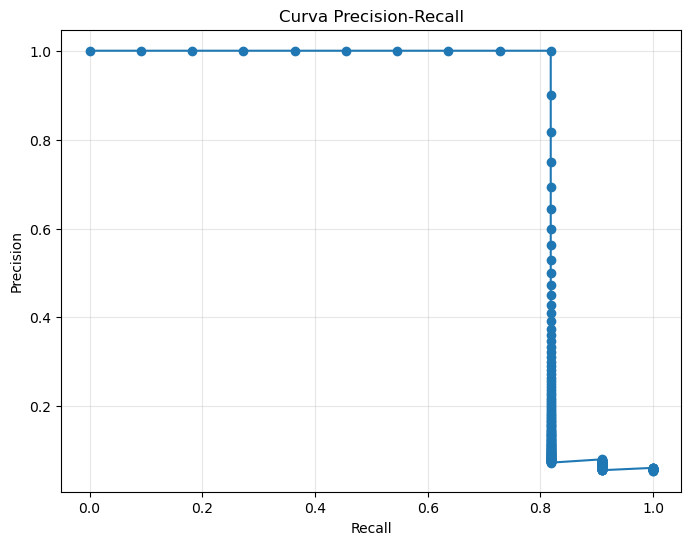

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    marker="o"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.grid(alpha=0.3)
plt.show()

In [15]:
tabela_pr = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_values[:-1],
    "Recall": recall_values[:-1]
})

tabela_pr[
    tabela_pr["Recall"] >= 0.80
].sort_values(
    "Precision",
    ascending=False
).head(10)

,Threshold,Precision,Recall
191,0.255996,1.000000,0.818182
190,0.227901,0.900000,0.818182
189,0.196293,0.818182,0.818182
188,0.162597,0.750000,0.818182
187,0.148881,0.692308,0.818182
186,0.147918,0.642857,0.818182
185,0.139592,0.600000,0.818182
184,0.139382,0.562500,0.818182
183,0.139381,0.529412,0.818182
182,0.125012,0.500000,0.818182


## 7. PR-AUC

A PR-AUC resume o desempenho do modelo ao longo da Curva Precision-Recall.

Enquanto um threshold específico produz uma combinação de Precision e Recall, a PR-AUC considera o comportamento do modelo ao longo de diferentes thresholds.

De forma geral, valores maiores indicam que o modelo consegue manter uma melhor combinação entre **Precision e Recall** ao variar o threshold.

A interpretação da PR-AUC deve considerar a prevalência da classe positiva, especialmente em problemas com classes desbalanceadas.

In [16]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_score
)

print("Average Precision:", pr_auc)

Average Precision: 0.8310997886597095


### Interpretação da Average Precision

Uma Average Precision alta indica que o modelo consegue manter boa Precision à medida que aumenta o Recall, ou seja, consegue recuperar uma parcela maior dos positivos reais sem gerar proporcionalmente muitos falsos positivos.

A Average Precision não representa acurácia, não corresponde à Precision de um threshold específico e não determina qual threshold deve ser utilizado.

Sua interpretação deve considerar também a prevalência da classe positiva e o objetivo do negócio.

## 8. Comparação entre ROC e Precision-Recall

As curvas ROC e Precision-Recall avaliam o mesmo modelo a partir dos seus scores, mas observam perspectivas diferentes.

- **ROC:** compara TPR (Recall) e FPR em diferentes thresholds.
- **Precision-Recall:** compara Precision e Recall em diferentes thresholds.

A comparação é especialmente importante em bases desbalanceadas, pois um FPR aparentemente baixo pode ainda representar uma quantidade relevante de falsos positivos.

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_score
)

roc_auc = roc_auc_score(
    y_test,
    y_score
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8643578643578644


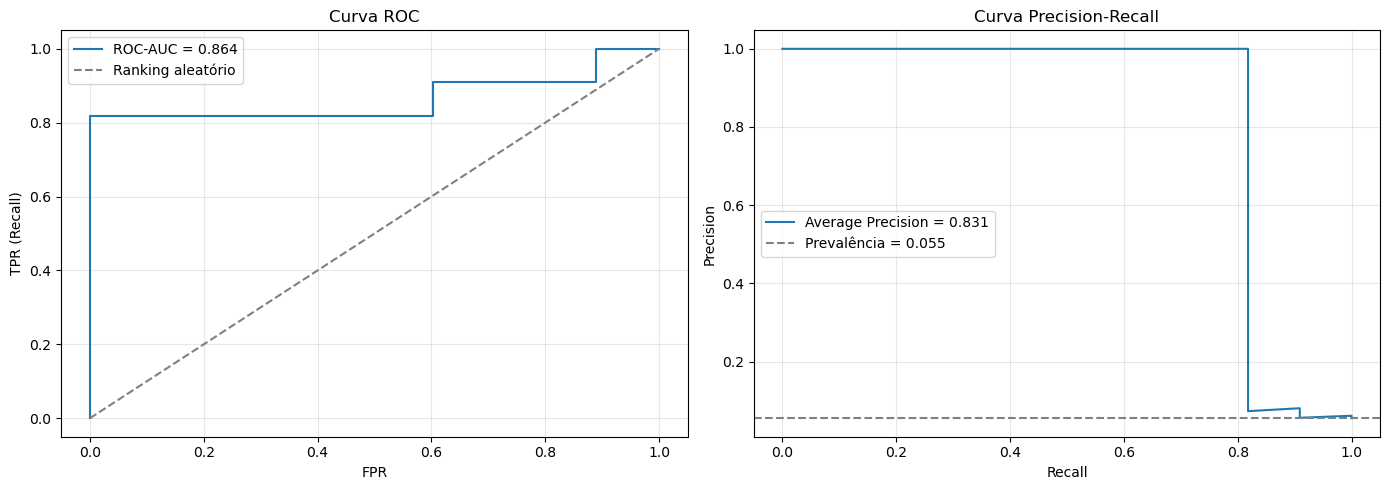

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Ranking aleatório"
)

axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR (Recall)")
axes[0].set_title("Curva ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Curva Precision-Recall
axes[1].plot(
    recall_values,
    precision_values,
    label=f"Average Precision = {pr_auc:.3f}"
)

axes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalência = {y_test.mean():.3f}"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretação da comparação

A ROC-AUC de aproximadamente 0,86 indica que o modelo apresenta boa capacidade de discriminação entre as classes.

Entretanto, em uma base desbalanceada, a ROC deve ser analisada em conjunto com métricas que observam mais diretamente o comportamento da classe positiva.

A Average Precision de aproximadamente 0,83, frente a uma prevalência positiva de 5,5%, indica que o modelo consegue manter boa Precision enquanto recupera uma parcela relevante dos positivos.

A Curva Precision-Recall mostra, porém, que após determinado nível de Recall, aumentar a recuperação dos positivos exige aceitar mais falsos positivos, reduzindo significativamente a Precision.

Assim, ROC-AUC e Average Precision ajudam a avaliar o modelo, enquanto a escolha do threshold operacional deve considerar os objetivos do negócio e os custos associados aos Falsos Positivos e Falsos Negativos.

## 9. Matthews Correlation Coefficient (MCC)

O MCC (Matthews Correlation Coefficient) é uma métrica de avaliação para classificação binária que considera simultaneamente os quatro componentes da matriz de confusão:

- Verdadeiros Positivos (VP);
- Verdadeiros Negativos (VN);
- Falsos Positivos (FP);
- Falsos Negativos (FN).

Por considerar toda a matriz de confusão, o MCC pode ser especialmente útil na avaliação de modelos em bases desbalanceadas.

O MCC varia de **-1 a +1**:

- **+1:** classificação perfeita;
- **0:** pouca ou nenhuma associação entre as previsões e as classes reais;
- **-1:** discordância perfeita entre previsão e realidade.

In [19]:
from sklearn.metrics import matthews_corrcoef

# Threshold 0.50
y_pred_050 = (y_score >= 0.50).astype(int)
mcc_050 = matthews_corrcoef(y_test, y_pred_050)

# Threshold escolhido a partir da análise da PR Curve
threshold_otimizado = 0.255996
y_pred_0256 = (y_score >= threshold_otimizado).astype(int)
mcc_0256 = matthews_corrcoef(y_test, y_pred_0256)

print("MCC - Threshold 0.50:", mcc_050)
print("MCC - Threshold 0.256:", mcc_0256)

MCC - Threshold 0.50: 0.592156525463792
MCC - Threshold 0.256: 0.8997857907859699


### Interpretação do MCC

Com o threshold padrão de 0,50, o modelo apresentou MCC de aproximadamente 0,59.

Ao utilizar um threshold de aproximadamente 0,256, identificado durante a análise da curva Precision-Recall, o MCC aumentou para aproximadamente 0,90.

Nesse intervalo, a redução do threshold permitiu aumentar os Verdadeiros Positivos de 4 para 9 e reduzir os Falsos Negativos de 7 para 2, sem aumentar os Falsos Positivos.

O resultado mostra que o threshold influencia não apenas Precision e Recall, mas também o equilíbrio global da matriz de confusão e, consequentemente, o MCC.

Entretanto, não se deve concluir que thresholds menores sempre produzem MCC maior. O comportamento depende da distribuição dos scores e dos erros gerados em cada ponto de corte.

Além disso, como o conjunto de teste possui poucos casos positivos, o threshold de aproximadamente 0,256 deve ser considerado um candidato e seu desempenho deve ser validado em outras amostras antes de uma decisão operacional.

In [21]:
from scipy.stats import ks_2samp

scores_negativos = y_score[y_test == 0]
scores_positivos = y_score[y_test == 1]

ks_statistic, p_value = ks_2samp(
    scores_negativos,
    scores_positivos
)

print(f"KS: {ks_statistic:.3f}")

KS: 0.818


In [22]:
ks_roc = max(tpr - fpr)

print("KS pela ROC:", ks_roc)

KS pela ROC: 0.8181818181818182


## 10. Kolmogorov-Smirnov (KS)

O KS avalia a capacidade de separação entre as distribuições dos scores das classes positiva e negativa.

A métrica considera as distribuições acumuladas dos scores e identifica o ponto em que a distância entre elas é máxima.

Em problemas de classificação binária, o KS também pode ser obtido a partir da curva ROC:

\[
KS = \max(TPR - FPR)
\]

Quanto maior o KS, maior a separação observada entre as distribuições dos scores das duas classes. Entretanto, sua interpretação deve considerar o contexto do problema e a amostra utilizada.

In [23]:
import numpy as np

diferenca_ks = tpr - fpr

indice_ks = np.argmax(diferenca_ks)

ks_max = diferenca_ks[indice_ks]
threshold_ks = thresholds_roc[indice_ks]
tpr_ks = tpr[indice_ks]
fpr_ks = fpr[indice_ks]

print("KS máximo:", ks_max)
print("Threshold no KS máximo:", threshold_ks)
print("TPR:", tpr_ks)
print("FPR:", fpr_ks)

KS máximo: 0.8181818181818182
Threshold no KS máximo: 0.25599630194656525
TPR: 0.8181818181818182
FPR: 0.0


### Interpretação do experimento

O modelo apresentou KS de aproximadamente 0,818, indicando uma forte separação entre as distribuições dos scores das classes positiva e negativa nesta amostra.

A separação máxima ocorreu em um threshold de aproximadamente 0,256. Nesse ponto, o TPR (Recall) foi de aproximadamente 81,8% e o FPR foi de 0%, resultando em:

\[
KS = 0,818 - 0 = 0,818
\]

Esse mesmo threshold já havia se destacado na análise da curva Precision-Recall, atendendo ao requisito de Recall mínimo de 80% com Precision de 100%, e também apresentou MCC de aproximadamente 0,90.

A coincidência entre os thresholds ocorre neste experimento, mas não é uma regra, pois cada métrica utiliza um critério diferente de avaliação.